In [4]:
# Работа с изображениями
from PIL import Image
import imageio
import cv2
from keras.preprocessing.image import img_to_array

# Библиотека линейной алгебры
import numpy as np

# Работа с файловой системой и системными функциями
import os

# Подготовка данных
from keras import preprocessing
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import tensorflow_datasets as tfds

# Построение сети
from keras.models import Sequential
from keras.layers import Conv2D,Dropout,Dense,Flatten,Conv2DTranspose,BatchNormalization,LeakyReLU,Reshape

# Визуализация выполнения процессов, циклов
from tqdm import tqdm

# Генерация случайных чисел
import re

# Работа с графиками
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Отключаем лишние предупреждения
import warnings
warnings.filterwarnings('ignore')

Загрузка датасета

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
dataset_info = tfds.builder('fashion_mnist').info

Получение всех классов датасета

In [6]:
class_names = dataset_info.features['label'].names
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Фцнкции отрисовки 10 изображений датасета

In [7]:
def show_sample_images(x_data, y_data, class_names, num_samples=10):
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        plt.subplot(2, 5, i+1)  # 2 строки, 5 столбцов
        plt.imshow(x_data[i], cmap='gray')
        plt.title(f"{class_names[y_data[i]]}")
        plt.axis('off')

    plt.suptitle('Примеры изображений из Fashion MNIST', fontsize=16)
    plt.tight_layout()
    plt.show()

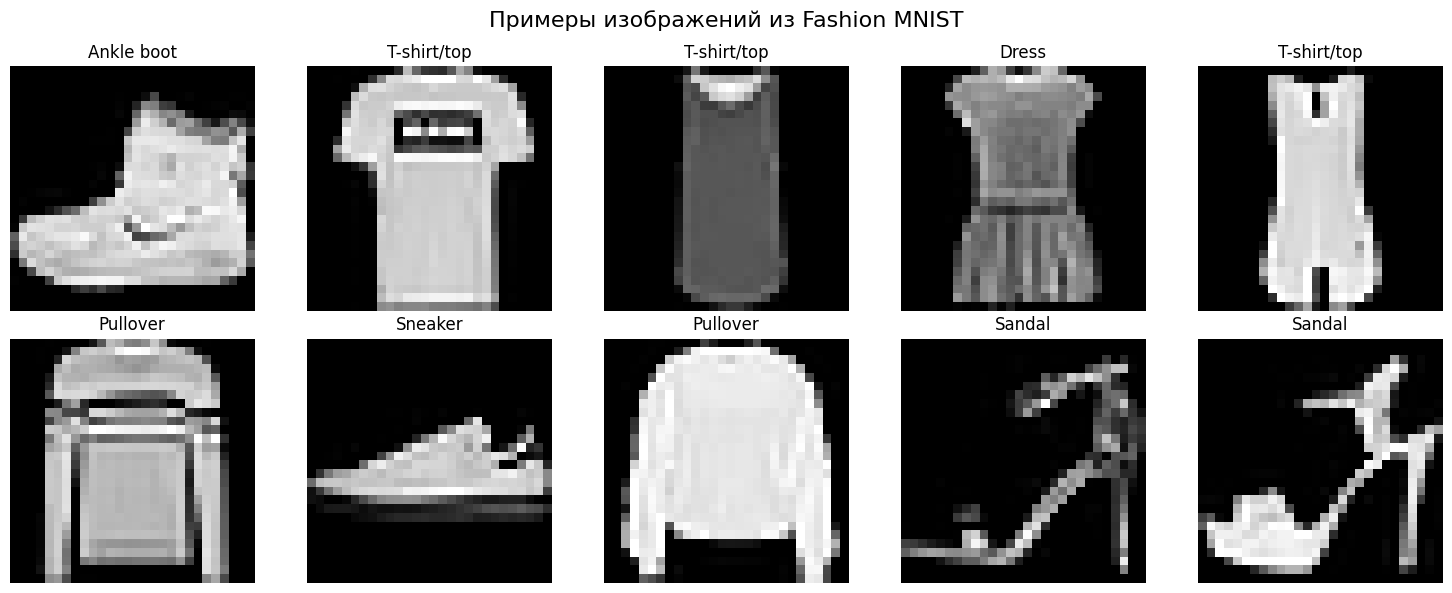

In [8]:
show_sample_images(x_train, y_train, class_names, 10)

Приступим к реализации модели

In [9]:
SIZE = 32  # Базовое количество фильтров
LATENT_DIM = 100  # Размерность шума
BATCH_SIZE = 128
EPOCHS = 50
INPUT_SHAPE = (28, 28, 1)  # Fashion MNIST размер

In [10]:
def create_generator():
    model = Sequential(name="Generator")

    # Входной слой
    model.add(Dense(7*7*SIZE*2, use_bias=False, input_shape=(LATENT_DIM,)))
    model.add(Reshape((7, 7, SIZE*2)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))

    # Первый апсемплинг: 7x7 -> 14x14
    model.add(Conv2DTranspose(SIZE*2, (4,4), strides=2, padding='same',
                              kernel_initializer='he_normal', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))

    # Второй апсемплинг: 14x14 -> 28x28
    model.add(Conv2DTranspose(SIZE, (4,4), strides=2, padding='same',
                              kernel_initializer='he_normal', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))

    # Выходной слой
    model.add(Conv2D(1, (4,4), strides=1, padding='same',
                     activation='tanh', kernel_initializer='he_normal'))

    return model

generator = create_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3136)           │       313,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        65,536 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,057 (1.58 MB)

 Trainable params: 412,737 (1.57 MB)

 Non-trainable params: 320 (1.25 KB)

In [11]:
def create_discriminator():
    model = Sequential(name="Discriminator")

    # Вход: 28x28x1
    model.add(Conv2D(SIZE, (4,4), strides=2, padding='same',
                     input_shape=INPUT_SHAPE, kernel_initializer='he_normal', use_bias=False))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    # 14x14 -> 7x7
    model.add(Conv2D(SIZE*2, (4,4), strides=2, padding='same',
                     kernel_initializer='he_normal', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    # 7x7 -> 4x4
    model.add(Conv2D(SIZE*4, (4,4), strides=2, padding='same',
                     kernel_initializer='he_normal', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

discriminator = create_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,169 (653.00 KB)

 Trainable params: 166,785 (651.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# Оптимизаторы (Adam обычно лучше для GAN)
optimizer_G = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
optimizer_D = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [13]:
x_train = (x_train.astype('float32') - 127.5) / 127.5

# Добавление канала
x_train = np.expand_dims(x_train, axis=-1)

# Создание tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=60000).batch(BATCH_SIZE)

print(f"Размер датасета: {x_train.shape}")
print(f"Диапазон значений: [{x_train.min()}, {x_train.max()}]")

Размер датасета: (60000, 28, 28, 1)
Диапазон значений: [-1.0, 1.0]


In [14]:
@tf.function
def train_step(images):
    # Генерируем шум
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Генерируем изображения
        generated_images = generator(noise, training=True)

        # Дискриминатор оценивает реальные и сгенерированные
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Вычисляем потери
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Вычисляем градиенты
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Применяем градиенты
    optimizer_G.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    optimizer_D.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [15]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(10, 10))

    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2.0, cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Эпоха {epoch + 1}')
    plt.tight_layout()
    plt.show()

Эпоха 5/50
Generator Loss: 1.3060
Discriminator Loss: 1.0412
--------------------------------------------------


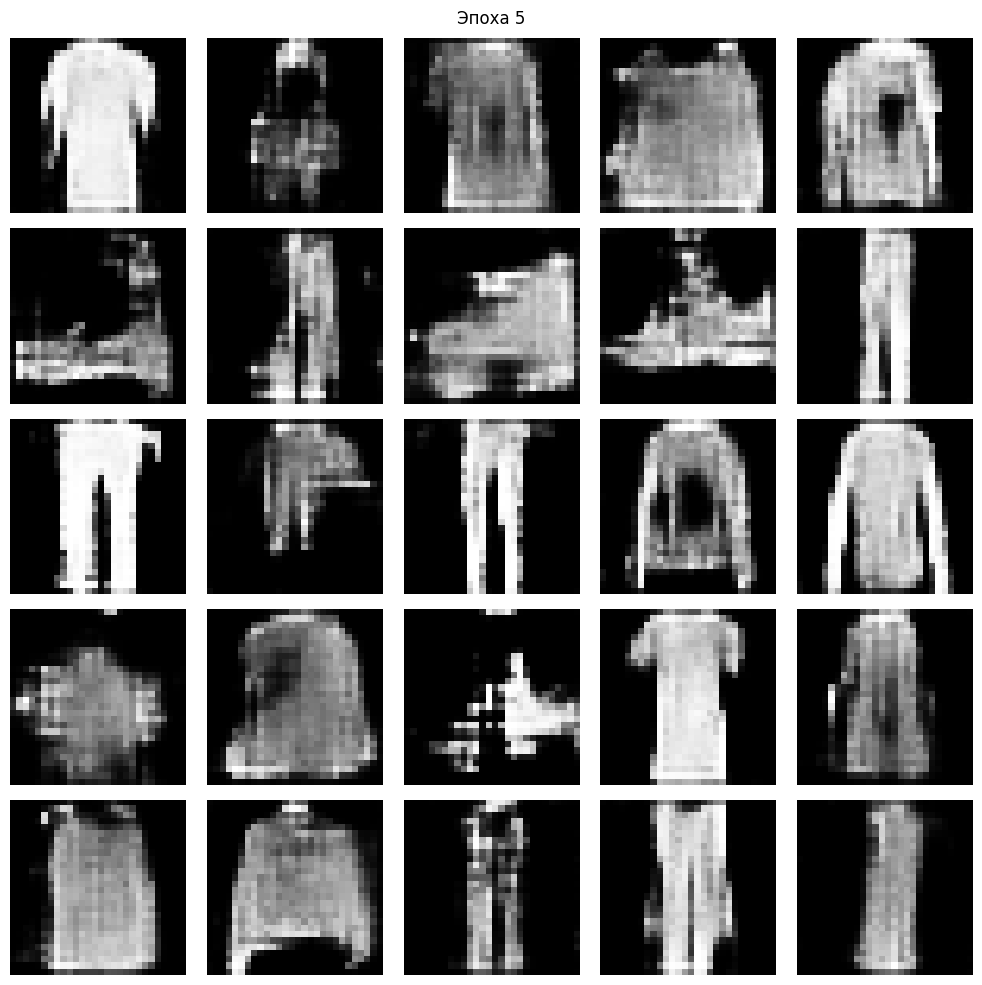

Эпоха 10/50
Generator Loss: 1.1556
Discriminator Loss: 1.1183
--------------------------------------------------


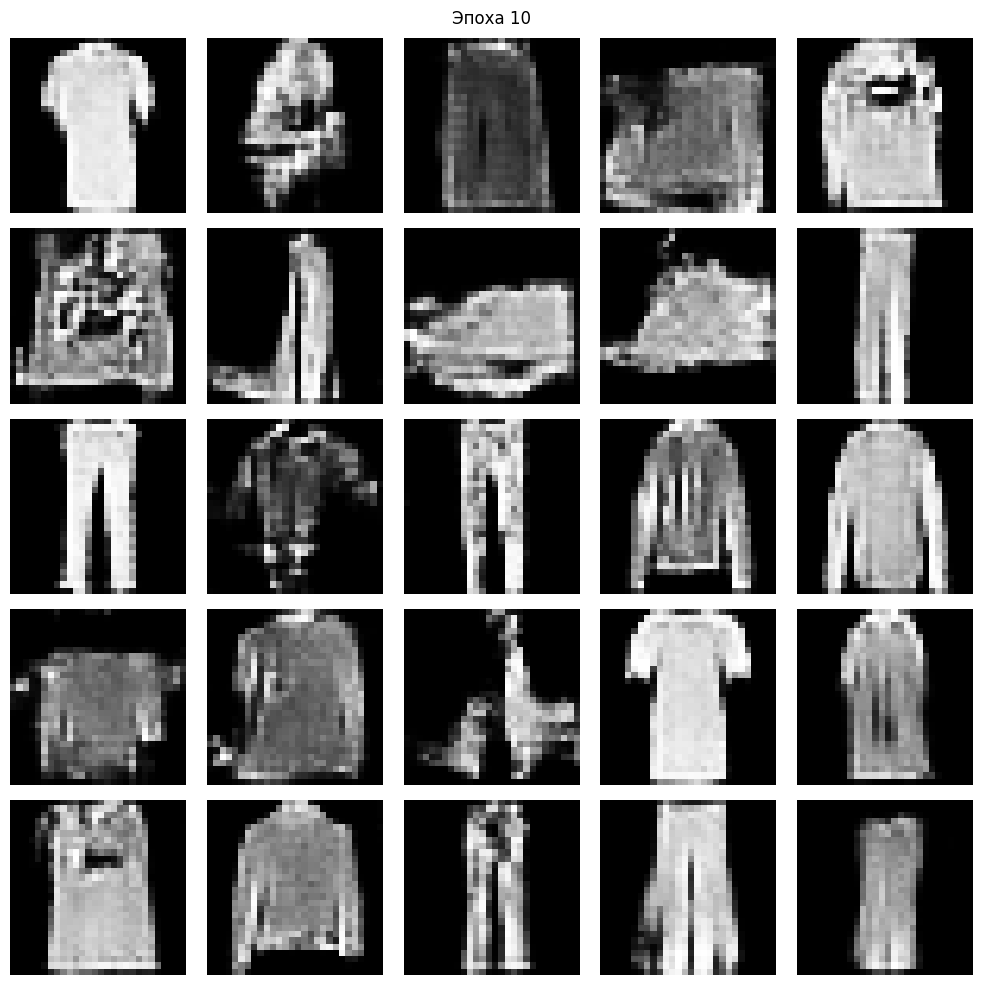

Эпоха 15/50
Generator Loss: 1.0923
Discriminator Loss: 1.1563
--------------------------------------------------


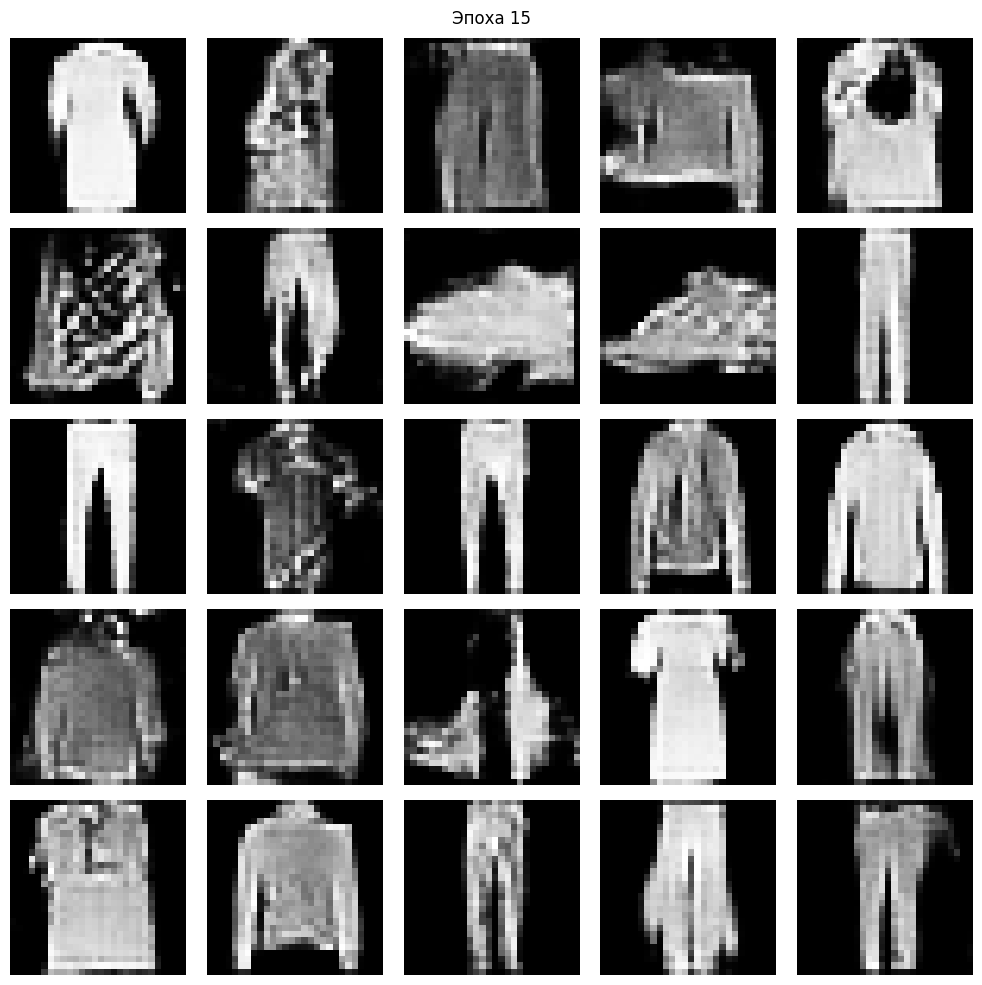

Эпоха 20/50
Generator Loss: 1.0875
Discriminator Loss: 1.1528
--------------------------------------------------


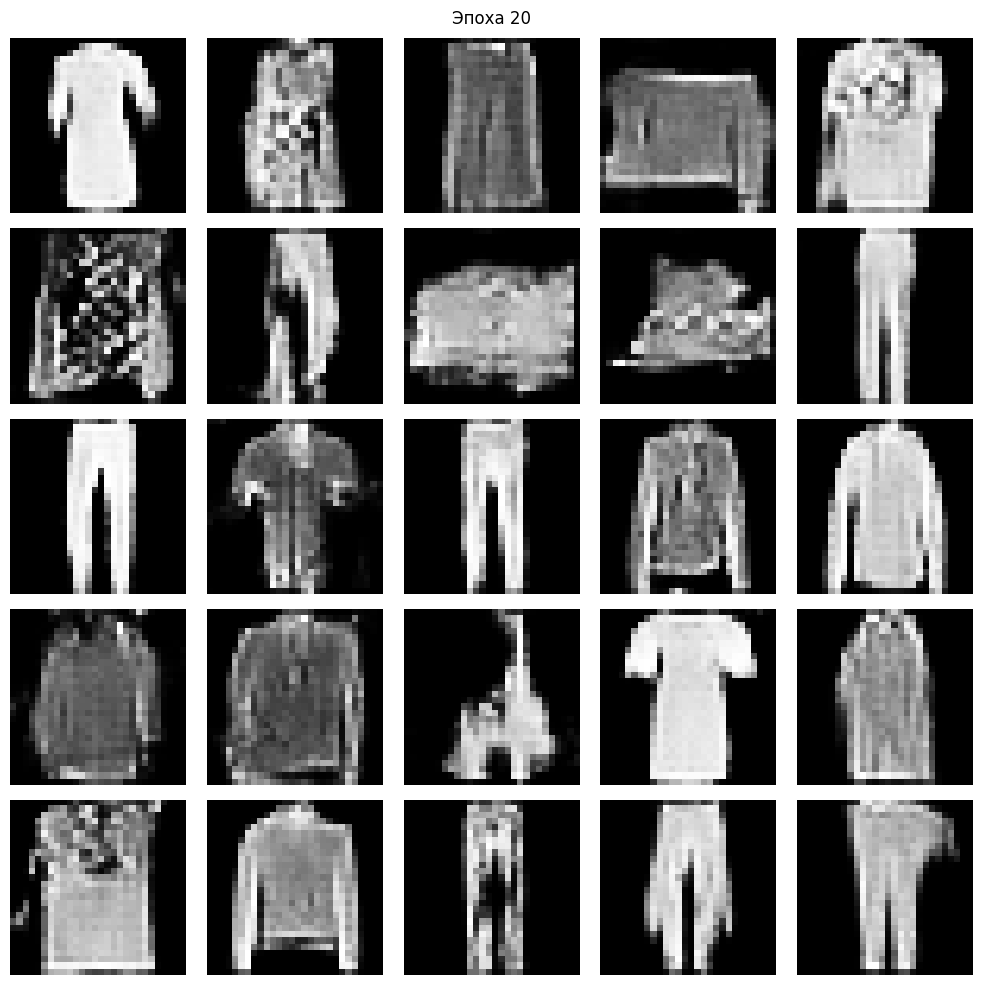

Эпоха 25/50
Generator Loss: 1.0915
Discriminator Loss: 1.1483
--------------------------------------------------


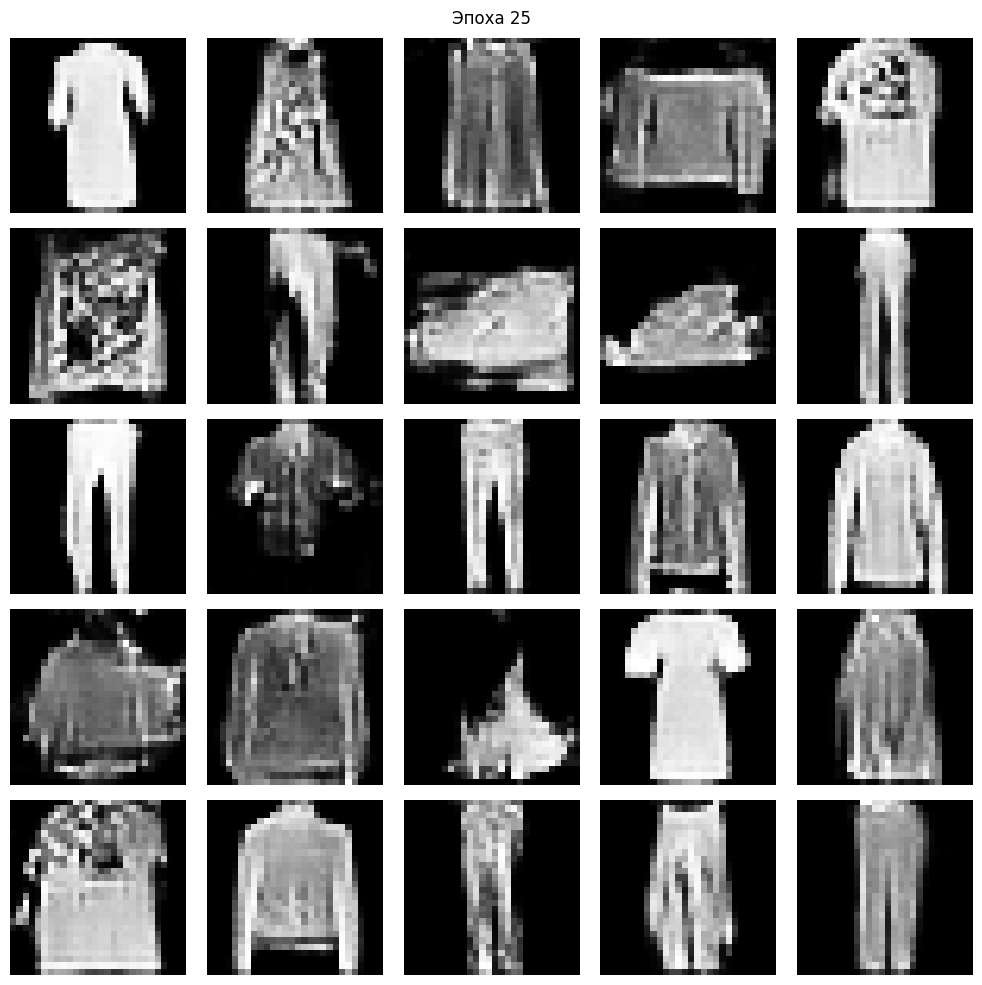

Эпоха 30/50
Generator Loss: 1.1053
Discriminator Loss: 1.1370
--------------------------------------------------


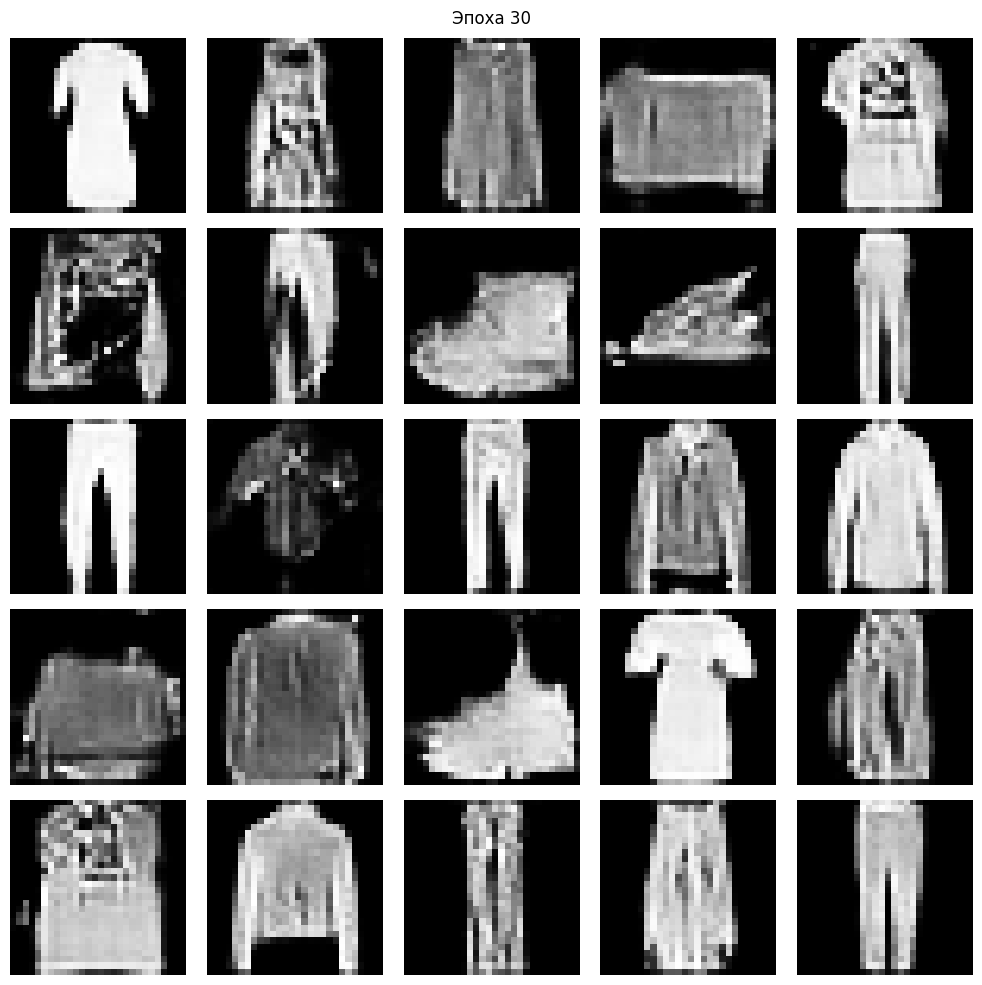

Эпоха 35/50
Generator Loss: 1.1175
Discriminator Loss: 1.1313
--------------------------------------------------


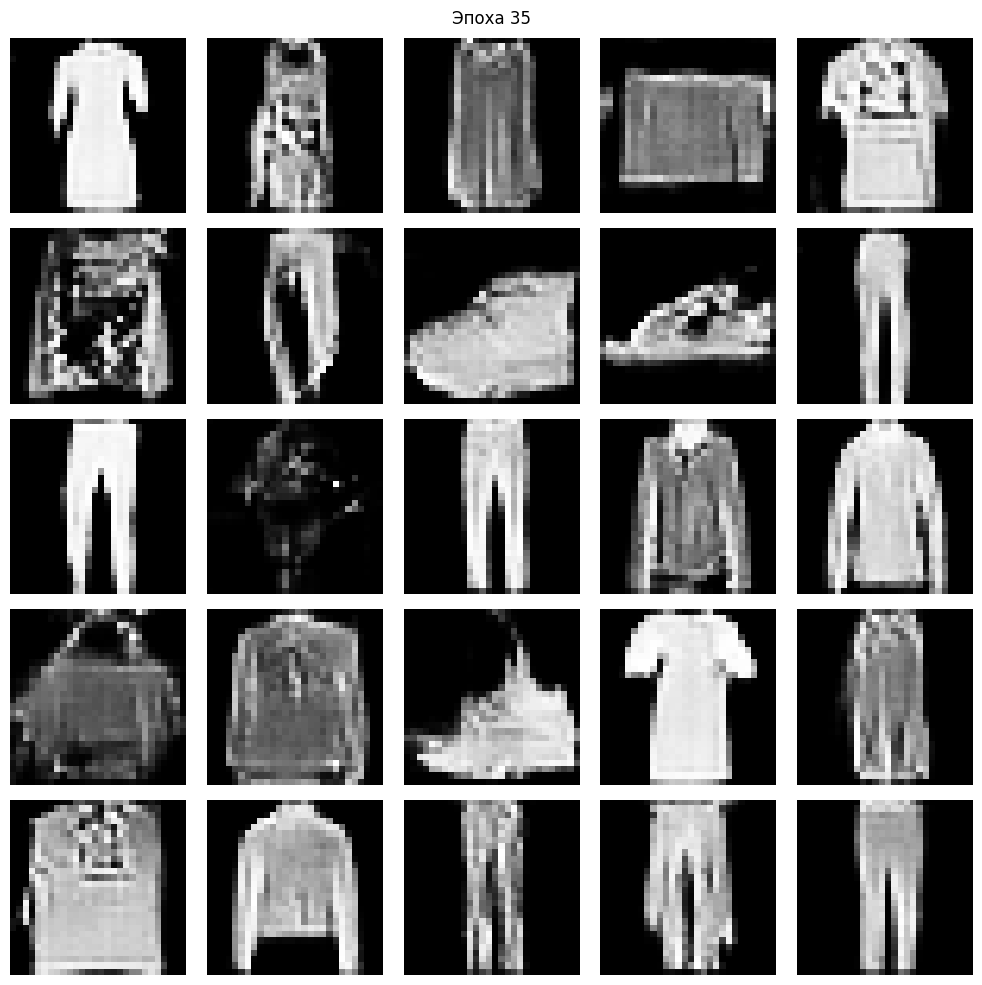

Эпоха 40/50
Generator Loss: 1.1430
Discriminator Loss: 1.1120
--------------------------------------------------


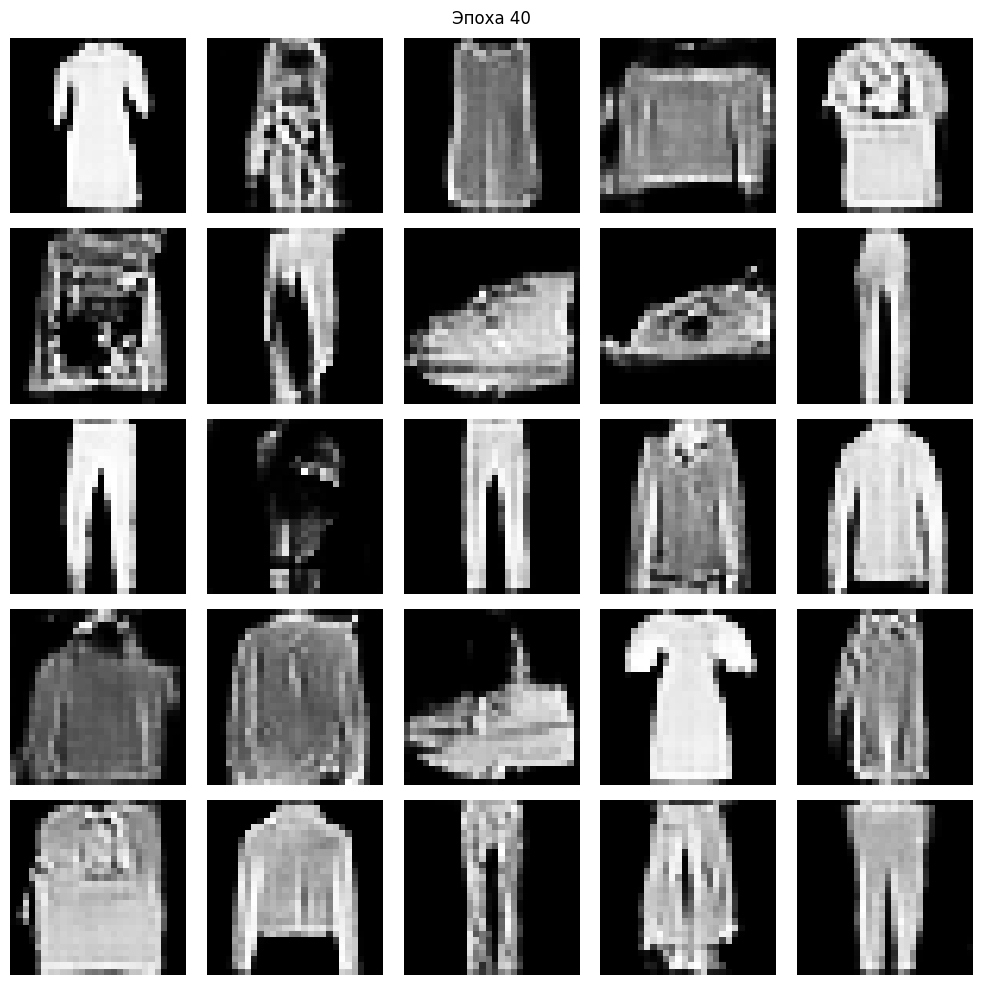

Эпоха 45/50
Generator Loss: 1.1505
Discriminator Loss: 1.1193
--------------------------------------------------


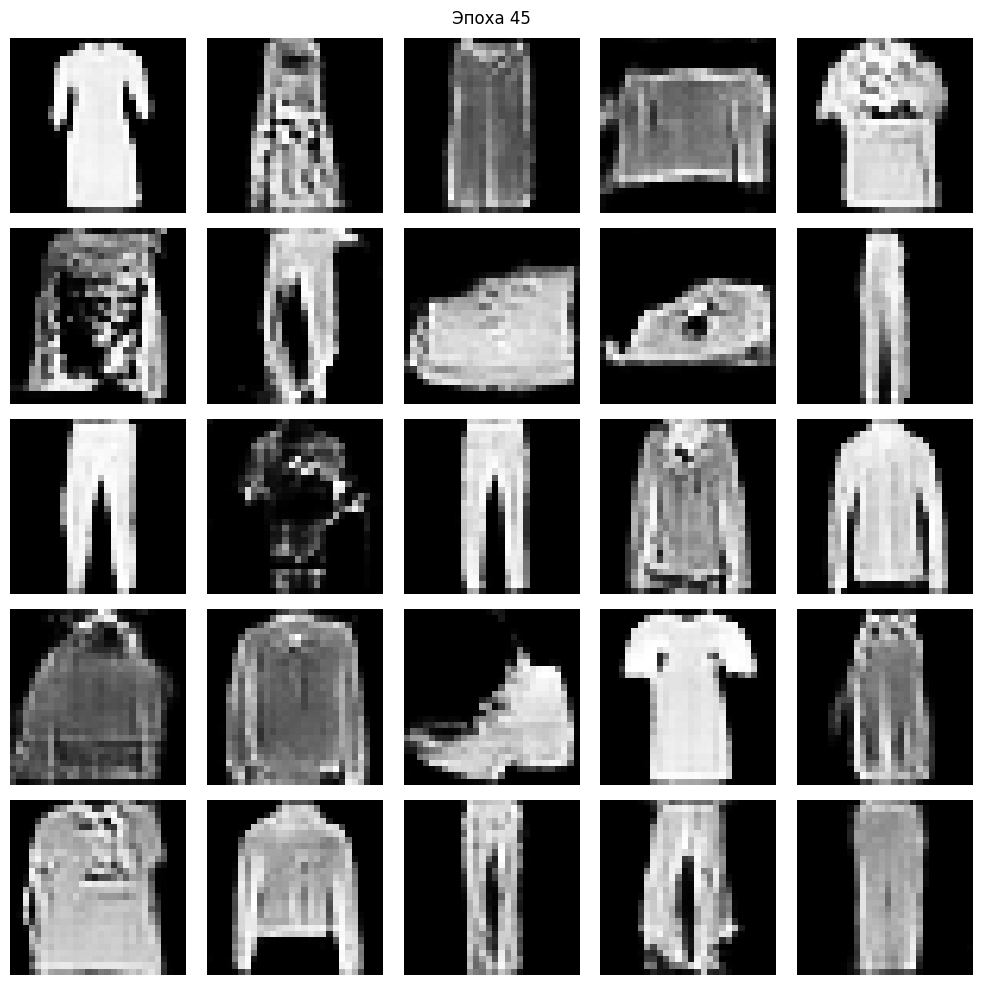

Эпоха 50/50
Generator Loss: 1.1910
Discriminator Loss: 1.0825
--------------------------------------------------


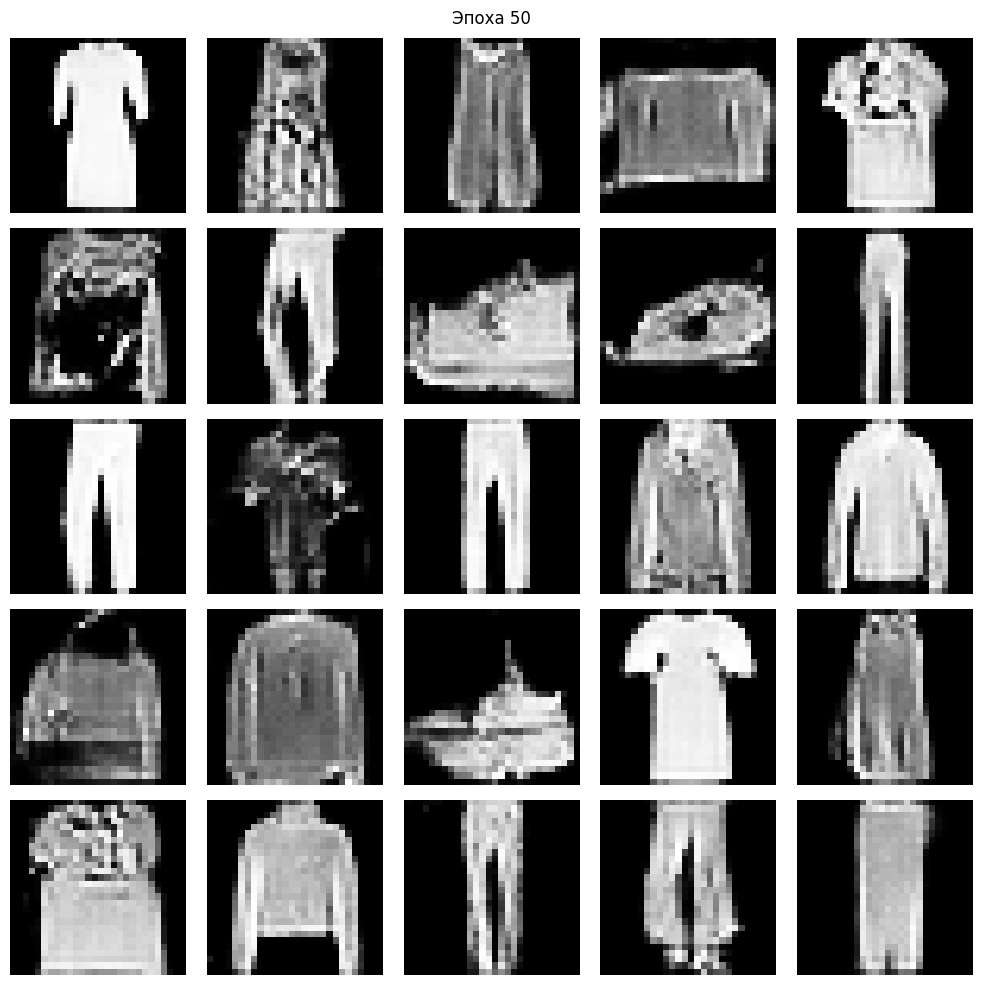

In [16]:
def train(dataset, epochs):
    # Фиксированный шум для визуализации прогресса
    seed = tf.random.normal([25, LATENT_DIM])

    history = {'gen_loss': [], 'disc_loss': []}

    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

        # Сохраняем средние потери за эпоху
        history['gen_loss'].append(np.mean(epoch_gen_loss))
        history['disc_loss'].append(np.mean(epoch_disc_loss))

        # Показываем прогресс каждые 5 эпох
        if (epoch + 1) % 5 == 0:
            print(f'Эпоха {epoch + 1}/{epochs}')
            print(f'Generator Loss: {history["gen_loss"][-1]:.4f}')
            print(f'Discriminator Loss: {history["disc_loss"][-1]:.4f}')
            print('-' * 50)

            # Генерируем и показываем изображения
            generate_and_save_images(generator, epoch, seed)

    return history

# Запуск обучения
history = train(dataset, EPOCHS)

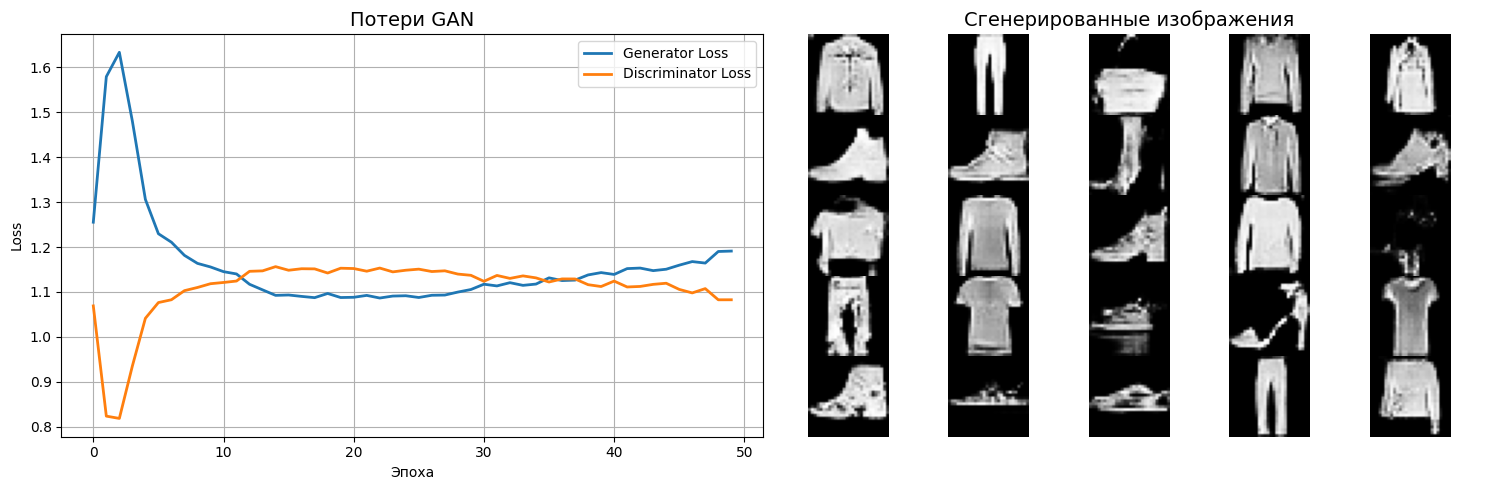

In [18]:
def plot_results(history):
    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь (на первой оси)
    axes[0].plot(history['gen_loss'], label='Generator Loss', linewidth=2)
    axes[0].plot(history['disc_loss'], label='Discriminator Loss', linewidth=2)
    axes[0].set_title('Потери GAN', fontsize=14)
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Генерируем финальные изображения
    noise = tf.random.normal([25, LATENT_DIM])
    generated_images = generator(noise, training=False)

    # Вторая ось для изображений
    for i in range(25):
        # Создаем сетку 5x5 внутри второй оси
        row = i // 5
        col = i % 5
        # Используем inset_axes или subplot внутри второй оси
        ax = axes[1].inset_axes([col/5, 1-(row+1)/5, 1/5, 1/5])
        img = (generated_images[i, :, :, 0].numpy() + 1) / 2.0
        ax.imshow(img, cmap='gray')
        ax.axis('off')

    axes[1].set_title('Сгенерированные изображения', fontsize=14)
    axes[1].axis('off')  # Отключаем оси для второй оси

    plt.tight_layout()
    plt.show()

# Показываем результаты
plot_results(history)